In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

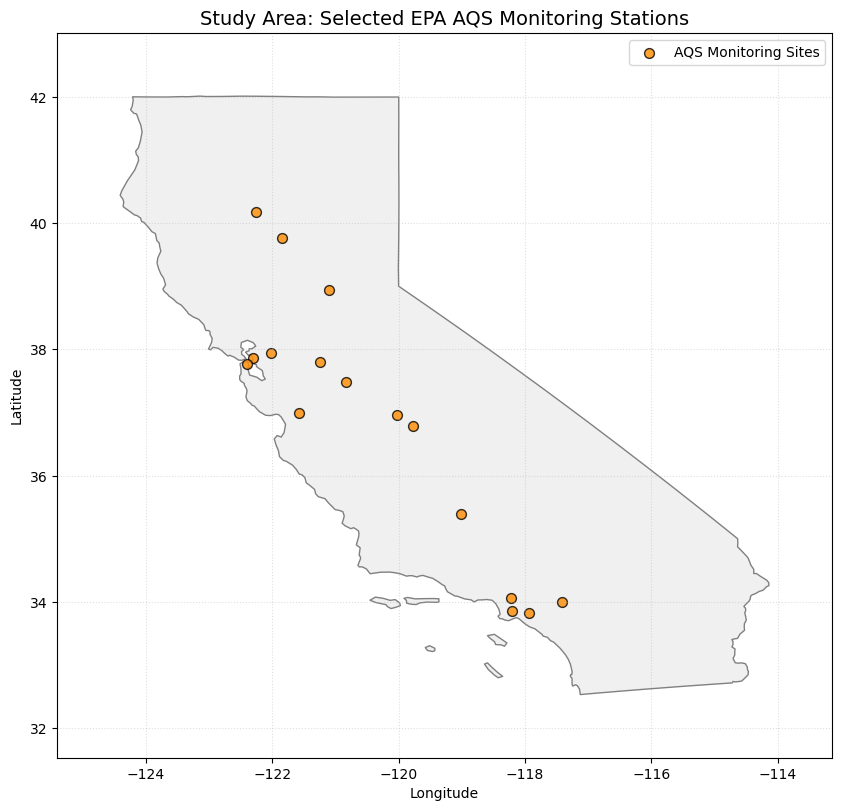

In [3]:
# 1. Load Data to get Lat/Lon (Use your original file before dropping columns)
# If 'pm25_complete_model_ready.parquet' has lat/lon, load it:
df_raw = pd.read_parquet("/Users/eric/Desktop/cali_air_quality/data/pm25_complete_model_ready.parquet") 

# 2. Extract Unique Stations with Coordinates
# Assuming columns are named 'latitude' and 'longitude' - adjust if 'lat'/'lon'
station_locations = df_raw[['site_id', 'latitude', 'longitude']].drop_duplicates()

# Convert to GeoDataFrame
geometry = [Point(xy) for xy in zip(station_locations['longitude'], station_locations['latitude'])]
gdf_stations = gpd.GeoDataFrame(station_locations, geometry=geometry)

# 3. Get California Map Background
# We can use the built-in US states dataset
usa = gpd.read_file("https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_state_20m.zip")
california = usa[usa['NAME'] == 'California']

# 4. Plot
fig, ax = plt.subplots(figsize=(10, 10))

# Plot California Base
california.plot(ax=ax, color='#f0f0f0', edgecolor='gray', linewidth=1)

# Plot Your Sites
gdf_stations.plot(
    ax=ax, 
    color='#FF8C00', # Orange color to match your TCN theme
    markersize=50, 
    edgecolor='black', 
    alpha=0.8,
    label='AQS Monitoring Sites'
)

# Add Labels (Optional - can get crowded)
# for x, y, label in zip(gdf_stations.geometry.x, gdf_stations.geometry.y, gdf_stations.site_id):
#     ax.annotate(label, xy=(x, y), xytext=(3, 3), textcoords="offset points", fontsize=8)

# Formatting to look like a Research Paper
plt.title('Study Area: Selected EPA AQS Monitoring Stations', fontsize=14)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.4)

# Zoom in to California bounds
minx, miny, maxx, maxy = california.total_bounds
ax.set_xlim(minx - 1, maxx + 1)
ax.set_ylim(miny - 1, maxy + 1)

plt.show()